In [1]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matpoltlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

print("All libraries imported successfully")

ModuleNotFoundError: No module named 'matpoltlib'

In [7]:
import sys 
print(sys.executable)

C:\Users\monda\AppData\Local\Programs\Python\Python312\python.exe


In [8]:
!where python

C:\Users\monda\AppData\Local\Programs\Python\Python312\python.exe
C:\Users\monda\AppData\Local\Microsoft\WindowsApps\python.exe


In [9]:
import sys 
!{sys.executable} -m pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

print("Success")

Success


In [11]:
df = pd.read_csv(r"C:\Users\monda\OneDrive\Desktop\ecommerce_data.csv")
print("success")

success


In [12]:
print(df.head())
print(df.info())

   InvoiceNo InvoiceDate  CustomerID  Quantity  UnitPrice
0     100000  12-06-2024        1028         1    3720.67
1     100001  03-03-2024        1057         3    3695.53
2     100002  22-06-2024        1189         9     480.35
3     100003  18-04-2024        1008         1     513.79
4     100004  29-02-2024        1129        10     181.35
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   int64  
 1   InvoiceDate  1000 non-null   str    
 2   CustomerID   1000 non-null   int64  
 3   Quantity     1000 non-null   int64  
 4   UnitPrice    1000 non-null   float64
dtypes: float64(1), int64(3), str(1)
memory usage: 39.2 KB
None


In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df = df[df['Quantity'] > 0]

In [15]:
df = df[df['UnitPrice'] > 0]

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

ValueError: time data "22-06-2024" doesn't match format "%m-%d-%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [17]:
print(df['InvoiceDate'].head(10))

0    12-06-2024
1    03-03-2024
2    22-06-2024
3    18-04-2024
4    29-02-2024
5    20-02-2024
6    24-04-2024
7    02-01-2024
8    28-03-2024
9    27-03-2024
Name: InvoiceDate, dtype: str


In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='%d-%m-%Y')

In [19]:
df['InvoiceDate'].head()

0   2024-06-12
1   2024-03-03
2   2024-06-22
3   2024-04-18
4   2024-02-29
Name: InvoiceDate, dtype: datetime64[us]

In [20]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,Quantity,UnitPrice,TotalPrice
0,100000,2024-06-12,1028,1,3720.67,3720.67
1,100001,2024-03-03,1057,3,3695.53,11086.59
2,100002,2024-06-22,1189,9,480.35,4323.15
3,100003,2024-04-18,1008,1,513.79,513.79
4,100004,2024-02-29,1129,10,181.35,1813.50


In [22]:
snapshot_date =df['InvoiceDate'].max() + timedelta(days=1)
print(snapshot_date)

2024-06-30 00:00:00


In [23]:
# calculate RFM Values
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda x:(snapshot_date - x.max()).days,'InvoiceNo':'count','TotalPrice':'sum'})

In [24]:
rfm.columns = ['Recency','Frequency','Monetary']
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
1000             29          6  94741.78
1001             82          3  23510.10
1002             18          6  92542.93
1003             65          2  12327.48
1004            101          4  57929.84


In [25]:
#Create rfm scores
rfm['R_Score'] = pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))
print(rfm.head())

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
CustomerID                                                                
1000             29          6  94741.78       2       3       3       233
1001             82          3  23510.10       1       1       1       111
1002             18          6  92542.93       3       3       3       333
1003             65          2  12327.48       1       1       1       111
1004            101          4  57929.84       1       2       2       122


In [26]:
# Customer Segmentation
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customer'
    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2:
        return 'At Risks'
    else:
        return 'Others'

In [27]:
rfm['Segment'] = rfm.apply(segment,axis=1)

In [28]:
summary = rfm.groupby('Segment').agg({'Recency':'mean','Frequency':'mean','Monetary':'mean'})
print(summary)

                       Recency  Frequency       Monetary
Segment                                                 
At Risks             59.242424   4.353535   63966.464343
Champions             3.555556   8.555556  124749.900000
Loyal Customer       11.842105   6.561404   86510.429825
Potential Loyalists   9.142857   3.371429   48215.916571


In [40]:
import os 
os.makedirs("plots",exist_ok=True)

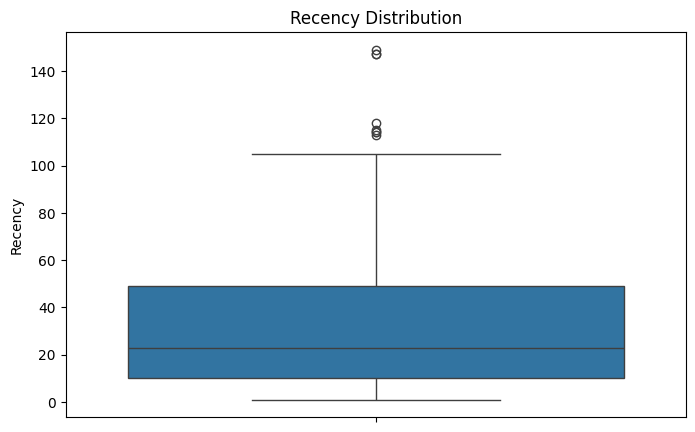

<Figure size 640x480 with 0 Axes>

In [41]:
# Visualizations
plt.figure(figsize=(8,5))
sns.boxplot(y=rfm['Recency'])
plt.title('Recency Distribution')
plt.savefig("plots/recency_boxplot.png")

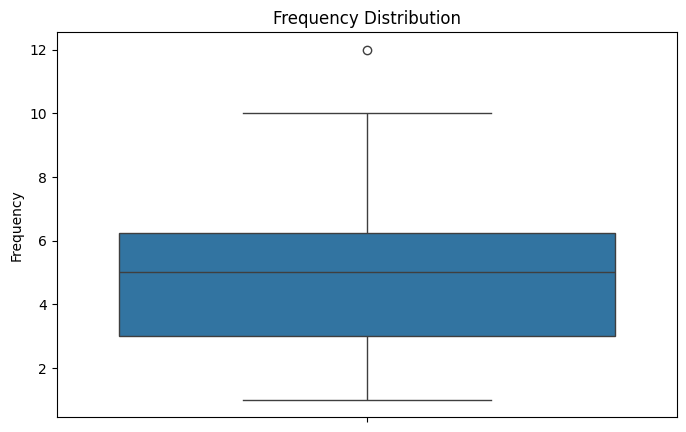

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(y=rfm['Frequency'])
plt.title('Frequency Distribution')
plt.savefig("plots/frequency_boxplot.png")
plt.show()

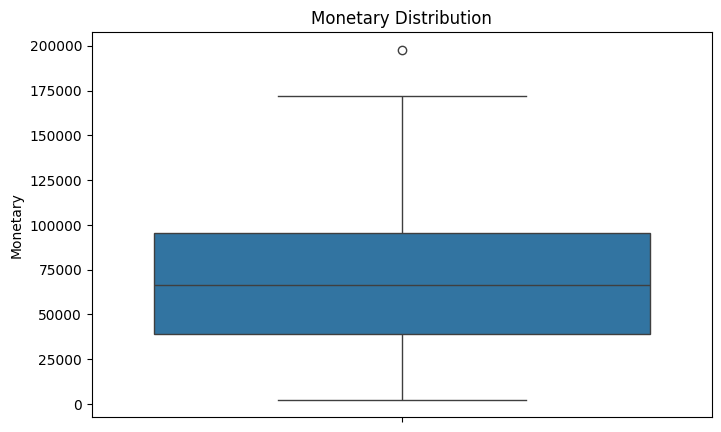

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary Distribution')
plt.savefig("plots/monetary_boxplot.png")
plt.show()

In [45]:
import os
print(os.listdir("plots"))

['frequency_boxplot.png', 'monetary_boxplot.png', 'recency_boxplot.png']


In [36]:
rfm.to_csv("customer_segments_rfm.csv")

In [46]:
import os 
print(os.getcwd())

C:\Users\monda\Documents
